In [ ]:
!pip -q install -U ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.3 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
model = YOLO("best.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
from google.colab import files
uploaded = files.upload()
img_path = next(iter(uploaded.keys()))
img_path

Saving IMG_2919.jpg to IMG_2919.jpg


'IMG_2919.jpg'

In [ ]:
vis_conf = 0.15  # low threshold so boxes still show up on the image

pred_results = model.predict(
    source=img_path,
    imgsz=640,
    conf=vis_conf,
    iou=0.5,
    save=True
)


image 1/1 /content/IMG_2919.jpg: 640x480 2 Dimes, 3 Nickels, 2 Pennys, 3 Quarters, 371.2ms
Speed: 16.7ms preprocess, 371.2ms inference, 42.3ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict


In [ ]:

from collections import Counter

VALUE_CENTS = {
    "penny": 1,
    "nickel": 5,
    "dime": 10,
    "quarter": 25,
}

count_conf = 0.60  # only include these in total

r = pred_results[0]
names = r.names

counts = Counter()
total_cents = 0

if r.boxes is not None and len(r.boxes) > 0:
    cls_ids = r.boxes.cls.cpu().numpy().astype(int)
    confs = r.boxes.conf.cpu().numpy()

    for cls_id, conf in zip(cls_ids, confs):
        cls_name = names[int(cls_id)].strip().lower()

        # Only COUNT if confidence >= 0.60
        if conf >= count_conf and cls_name in VALUE_CENTS:
            counts[cls_name] += 1
            total_cents += VALUE_CENTS[cls_name]

print("Counts (>=0.60):", dict(counts))
print(f"Total: {total_cents} cents = ${total_cents/100:.2f}")

Counts (>=0.60): {'nickel': 3, 'quarter': 3, 'dime': 2, 'penny': 2}
Total: 112 cents = $1.12


Saved predictions: runs/detect/predict/IMG_2919.jpg


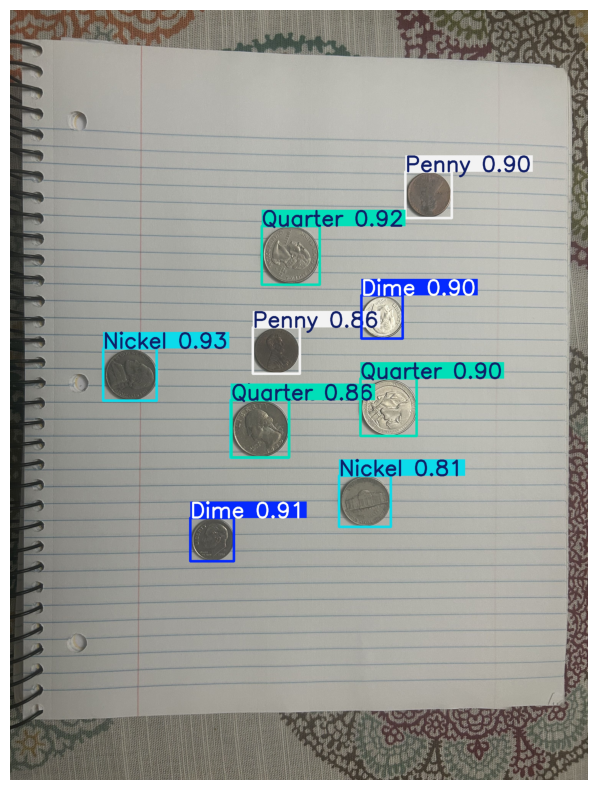

In [ ]:
import glob
from PIL import Image
from matplotlib import pyplot as plt

paths = sorted(glob.glob("runs/detect/predict*/" + img_path.split("/")[-1]))
print("Saved predictions:", paths[-1] if paths else "None found")

if paths:
    im = Image.open(paths[-1])
    plt.figure(figsize=(10,10))
    plt.imshow(im)
    plt.axis("off")
    plt.show()